### Bivariate Analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
sns.set_theme(style='whitegrid', palette='muted')

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
GRAY   = '#888780'

In [37]:
# ── Apply cleaning decisions from Phase 2 discussion ─────────────
df_dompet = pd.read_csv("../cleaned_dataset_revised_v3/dompet_final_cleaned_audit.csv")
df = df_dompet.copy()

# 1. Drop price outliers (>500K IDR — only 6 rows, non-representative)
df = df[df['final_price'] <= 500_000].copy()

# 2. Drop inactive/unrated listings
df = df[df['rating'] > 0].copy()

# 3. Winsorize reviews, sold, gmv_cal at 99th percentile
#    (caps extremes without removing real mega-seller signal)
for col in ['reviews', 'sold', 'gmv_cal']:
    cap = df[col].quantile(0.99)
    n_capped = (df[col] > cap).sum()
    df[col] = df[col].clip(upper=cap)
    print(f"  {col:10}: capped {n_capped} rows at {cap:,.0f}")

# 4. Create gmv_tier target label
df['gmv_tier'] = pd.qcut(df['gmv_cal'], q=[0,.33,.66,1],
                          labels=['low','mid','high'], duplicates='drop')

# 5. Create price_band for later use
df['price_band'] = pd.cut(df['final_price'],
    bins=[0,30000,60000,100000,200000,500000],
    labels=['<30K','30–60K','60–100K','100–200K','200–500K'])

print(f"\nCleaned dataset: {len(df):,} rows × {df.shape[1]} cols")
print(f"GMV tier counts:\n{df['gmv_tier'].value_counts().sort_index()}")

  reviews   : capped 42 rows at 7,837
  sold      : capped 42 rows at 9,452
  gmv_cal   : capped 42 rows at 730,276,640

Cleaned dataset: 4,149 rows × 39 cols
GMV tier counts:
gmv_tier
low     1370
mid     1368
high    1411
Name: count, dtype: int64


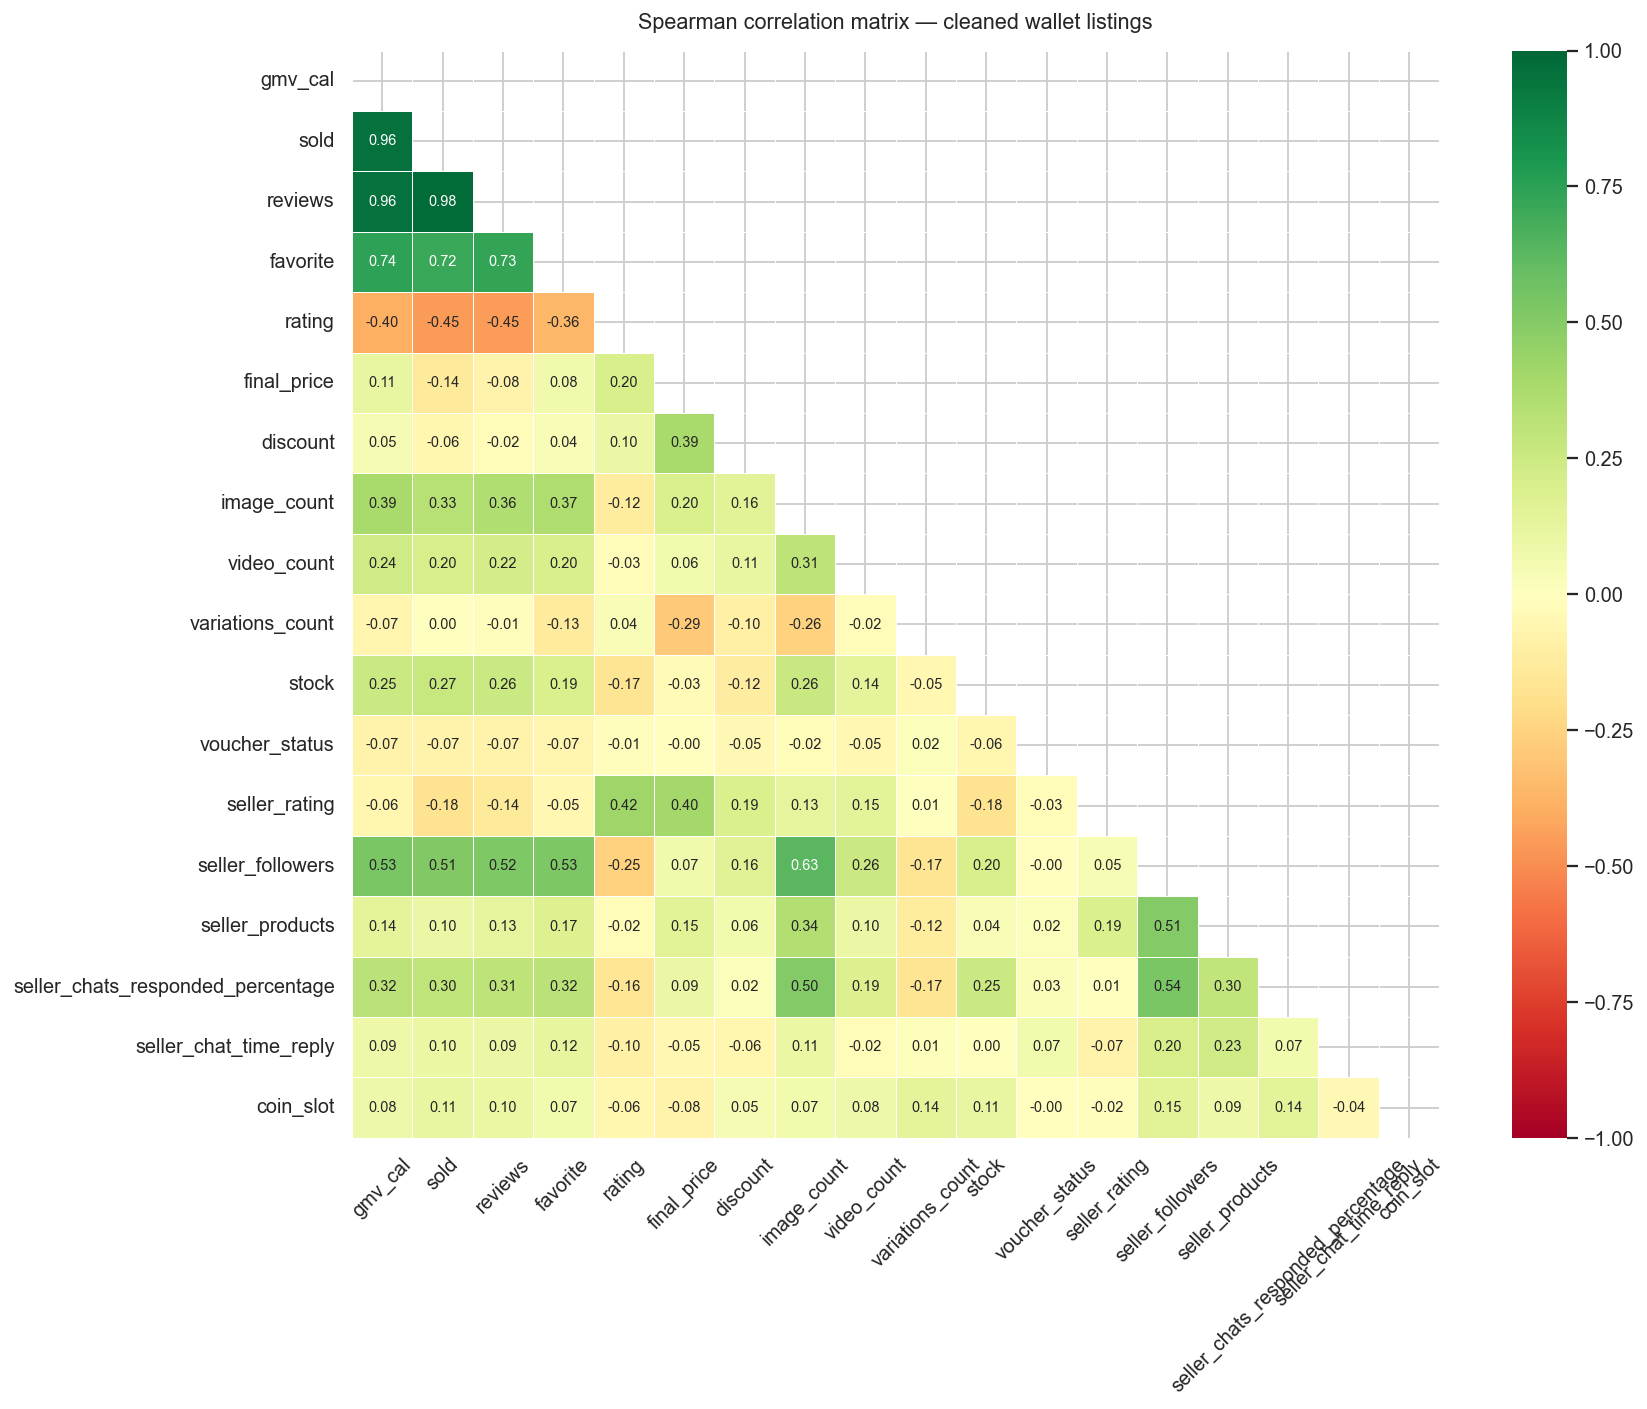


── Spearman ρ vs gmv_cal (ranked) ──
  sold                                     +0.961  ███████████████████
  reviews                                  +0.957  ███████████████████
  favorite                                 +0.743  ██████████████
  seller_followers                         +0.534  ██████████
  image_count                              +0.386  ███████
  seller_chats_responded_percentage        +0.318  ██████
  stock                                    +0.253  █████
  video_count                              +0.235  ████
  seller_products                          +0.136  ██
  final_price                              +0.111  ██
  seller_chat_time_reply                   +0.092  █
  coin_slot                                +0.084  █
  discount                                 +0.049  
  seller_rating                            -0.062  █
  variations_count                         -0.067  █
  voucher_status                           -0.071  █
  rating                             

In [46]:
# ── Master heatmap — which features correlate with GMV? ──────────
corr_cols = [
    'gmv_cal', 'sold', 'reviews', 'favorite', 'rating',
    'final_price', 'discount', 'image_count', 'video_count',
    'variations_count', 'stock', 'voucher_status',
    'seller_rating', 'seller_followers', 'seller_products',
    'seller_chats_responded_percentage', 'seller_chat_time_reply', 'coin_slot'
]

spearman_mx = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(spearman_mx, dtype=bool))
sns.heatmap(
    spearman_mx, mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white', square=True, ax=ax
)
ax.set_title('Spearman correlation matrix — cleaned wallet listings', fontsize=12, pad=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# Ranked correlations with gmv_cal
gmv_corr = spearman_mx['gmv_cal'].drop('gmv_cal').sort_values(ascending=False)
print("\n── Spearman ρ vs gmv_cal (ranked) ──")
for feat, val in gmv_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

sold_corr = spearman_mx['sold'].drop('sold').sort_values(ascending=False)
print("\n── Spearman ρ vs sold (ranked) ──")
for feat, val in sold_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

rating_corr = spearman_mx['rating'].drop('rating').sort_values(ascending=False)
print("\n── Spearman ρ vs rating (ranked) ──")
for feat, val in rating_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else ''
    print(f"  {feat:40} {sign}{val:.3f}  {bar}")

# Multicollinearity flag: sold vs gmv_cal
rho_sg, _ = stats.spearmanr(df['sold'], df['gmv_cal'])
print(f"\n⚠  sold vs gmv_cal ρ = {rho_sg:.3f}")
print("   If ρ > 0.85 → drop 'sold' as a feature; use gmv_cal as target only.")

#### [Insight] Sold vs gmv_cal have a very high correlation of > 0.85, meaning that they are essentially the same variable — to choose only one them moving forward as a target variable.

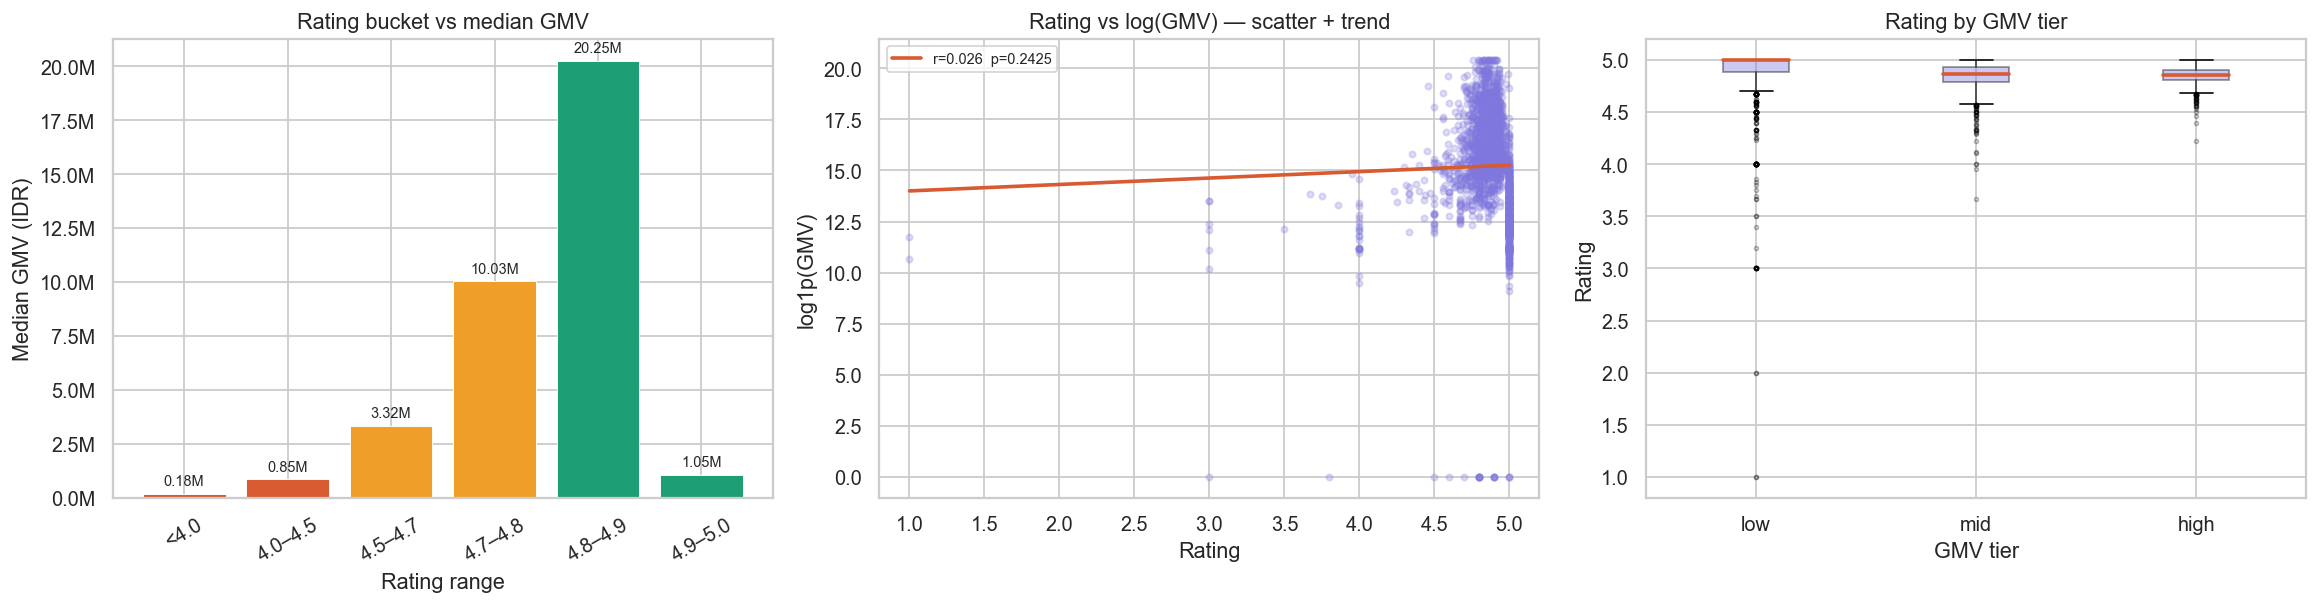


Spearman ρ (rating vs gmv_cal): -0.397  p=0.0000

── Median rating by GMV tier ──
          median   mean    std
gmv_tier                      
low         5.00  4.861  0.360
mid         4.87  4.847  0.136
high        4.86  4.849  0.076


In [39]:
# ── The rating threshold plot — most cited roadmap visual ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rating buckets vs median GMV — bar chart
df['rating_bucket'] = pd.cut(
    df['rating'],
    bins=[0, 4.0, 4.5, 4.7, 4.8, 4.9, 5.01],
    labels=['<4.0', '4.0–4.5', '4.5–4.7', '4.7–4.8', '4.8–4.9', '4.9–5.0']
)
bucket_gmv = df.groupby('rating_bucket', observed=True)['gmv_cal'].median()
bar_colors = [CORAL, CORAL, AMBER, AMBER, TEAL, TEAL]
axes[0].bar(bucket_gmv.index, bucket_gmv.values,
            color=bar_colors, edgecolor='white', lw=0.5)
axes[0].set_title('Rating bucket vs median GMV')
axes[0].set_xlabel('Rating range')
axes[0].set_ylabel('Median GMV (IDR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)
for i, (_, val) in enumerate(bucket_gmv.items()):
    axes[0].text(i, val + bucket_gmv.max()*0.02,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

# (b) Scatter: rating vs log(gmv) with regression
sample = df.sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample['rating'], np.log1p(sample['gmv_cal']),
               alpha=0.25, s=12, color=PURPLE)
m, b, r, p, _ = stats.linregress(
    sample['rating'], np.log1p(sample['gmv_cal']))
xs = np.linspace(sample['rating'].min(), sample['rating'].max(), 100)
axes[1].plot(xs, m*xs+b, color=CORAL, lw=2,
             label=f'r={r:.3f}  p={p:.4f}')
axes[1].set_title('Rating vs log(GMV) — scatter + trend')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('log1p(GMV)')
axes[1].legend(fontsize=8)

# (c) Boxplot: rating distribution per GMV tier
df.boxplot(column='rating', by='gmv_tier', ax=axes[2],
           patch_artist=True,
           boxprops=dict(facecolor=PURPLE, alpha=0.4),
           medianprops=dict(color=CORAL, lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.3))
axes[2].set_title('Rating by GMV tier')
axes[2].set_xlabel('GMV tier')
axes[2].set_ylabel('Rating')
fig.suptitle('')

plt.tight_layout()
plt.show()

rho_rg, pval_rg = stats.spearmanr(df['rating'], df['gmv_cal'])
print(f"\nSpearman ρ (rating vs gmv_cal): {rho_rg:.3f}  p={pval_rg:.4f}")
print("\n── Median rating by GMV tier ──")
print(df.groupby('gmv_tier', observed=True)['rating']
      .agg(['median','mean','std']).round(3))

#### [Insight] As most sellers have > 4.8 rating, the correlation between rating and gmv is not as intuitive. The bar chart visualizes with red bars = danger zone, teal bars = where high-GMV sellers are.

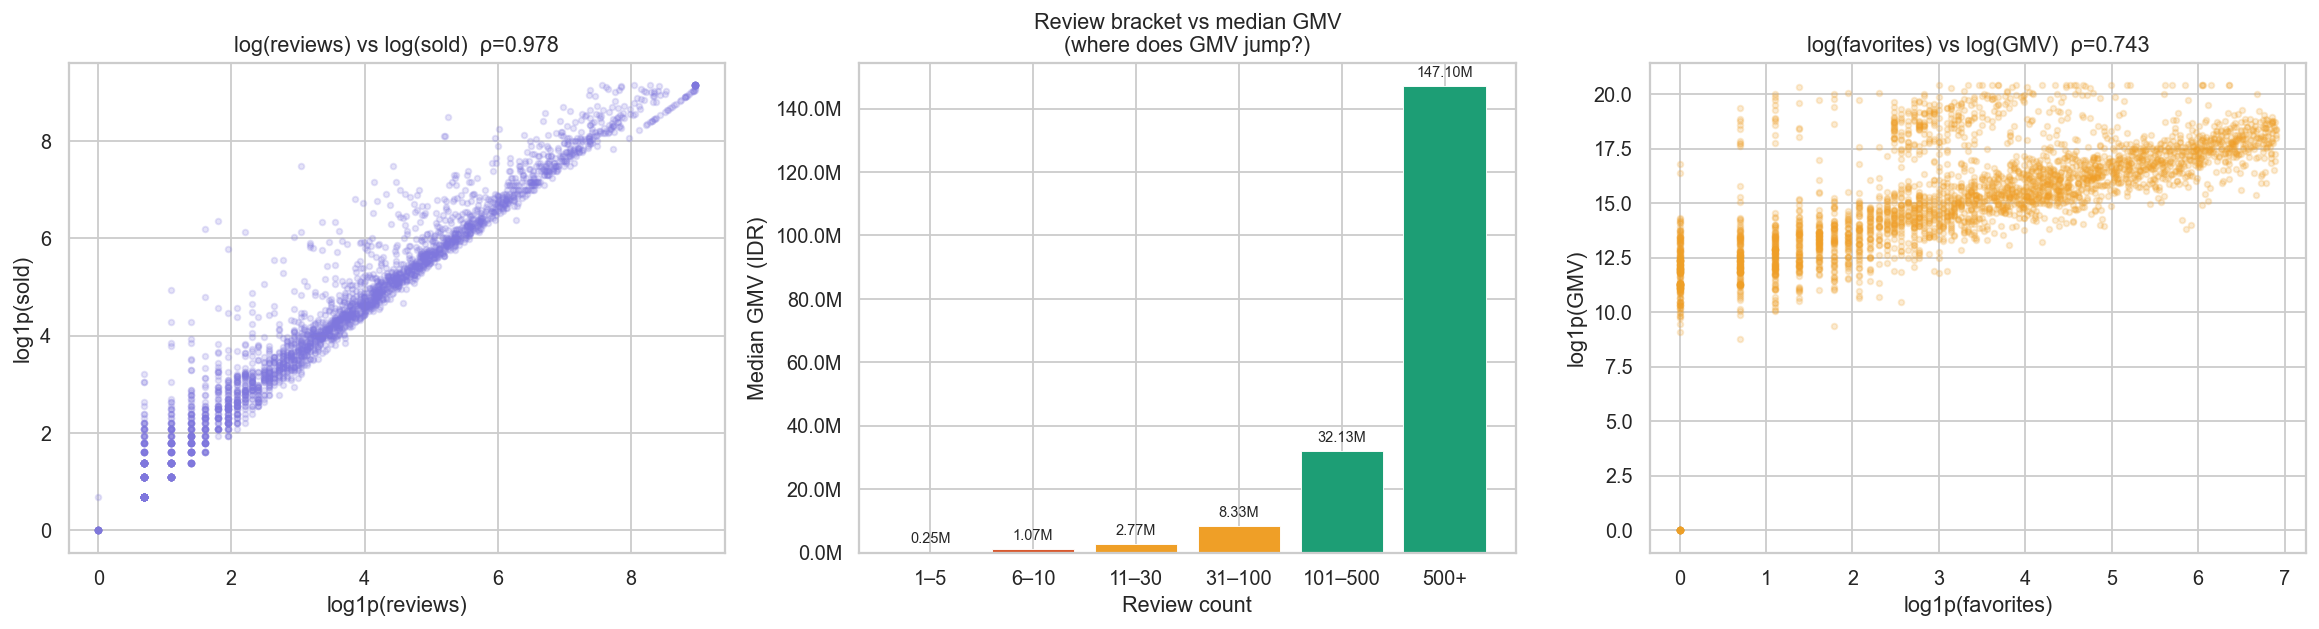


── Review bracket: count of listings + median GMV ──
                n_listings  median_gmv_M
review_bracket                          
1–5                   1023         0.250
6–10                   406         1.072
11–30                  626         2.768
31–100                 761         8.331
101–500                742        32.127
500+                   556       147.100


In [40]:
# ── Where exactly does the GMV jump as reviews accumulate? ────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sample = df.sample(min(3000, len(df)), random_state=42)

# (a) log(reviews) vs log(sold) — confirm flywheel
axes[0].scatter(np.log1p(sample['reviews']),
               np.log1p(sample['sold']),
               alpha=0.2, s=10, color=PURPLE)
rho_rs, _ = stats.spearmanr(df['reviews'], df['sold'])
axes[0].set_title(f'log(reviews) vs log(sold)  ρ={rho_rs:.3f}')
axes[0].set_xlabel('log1p(reviews)')
axes[0].set_ylabel('log1p(sold)')

# (b) Review bracket vs median GMV — find the tipping point
review_bins   = [0, 5, 10, 30, 100, 500, 99999]
review_labels = ['1–5', '6–10', '11–30', '31–100', '101–500', '500+']
df['review_bracket'] = pd.cut(
    df['reviews'], bins=review_bins, labels=review_labels)
bracket_stats = df.groupby('review_bracket', observed=True)['gmv_cal'].median()
bar_colors_r  = [CORAL, CORAL, AMBER, AMBER, TEAL, TEAL]
axes[1].bar(bracket_stats.index, bracket_stats.values,
            color=bar_colors_r, edgecolor='white', lw=0.5)
axes[1].set_title('Review bracket vs median GMV\n(where does GMV jump?)')
axes[1].set_xlabel('Review count')
axes[1].set_ylabel('Median GMV (IDR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
for i, (_, val) in enumerate(bracket_stats.items()):
    axes[1].text(i, val + bracket_stats.max()*0.02,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

# (c) Favorites vs GMV — vanity metric or real signal?
axes[2].scatter(np.log1p(sample['favorite']),
               np.log1p(sample['gmv_cal']),
               alpha=0.2, s=10, color=AMBER)
rho_fg, _ = stats.spearmanr(df['favorite'], df['gmv_cal'])
axes[2].set_title(f'log(favorites) vs log(GMV)  ρ={rho_fg:.3f}')
axes[2].set_xlabel('log1p(favorites)')
axes[2].set_ylabel('log1p(GMV)')

plt.tight_layout()
plt.show()

print("\n── Review bracket: count of listings + median GMV ──")
print(df.groupby('review_bracket', observed=True)
      .agg(n_listings=('gmv_cal','size'), median_gmv=('gmv_cal','median'))
      .assign(median_gmv_M=lambda x: (x['median_gmv']/1e6).round(3))
      .drop(columns='median_gmv'))

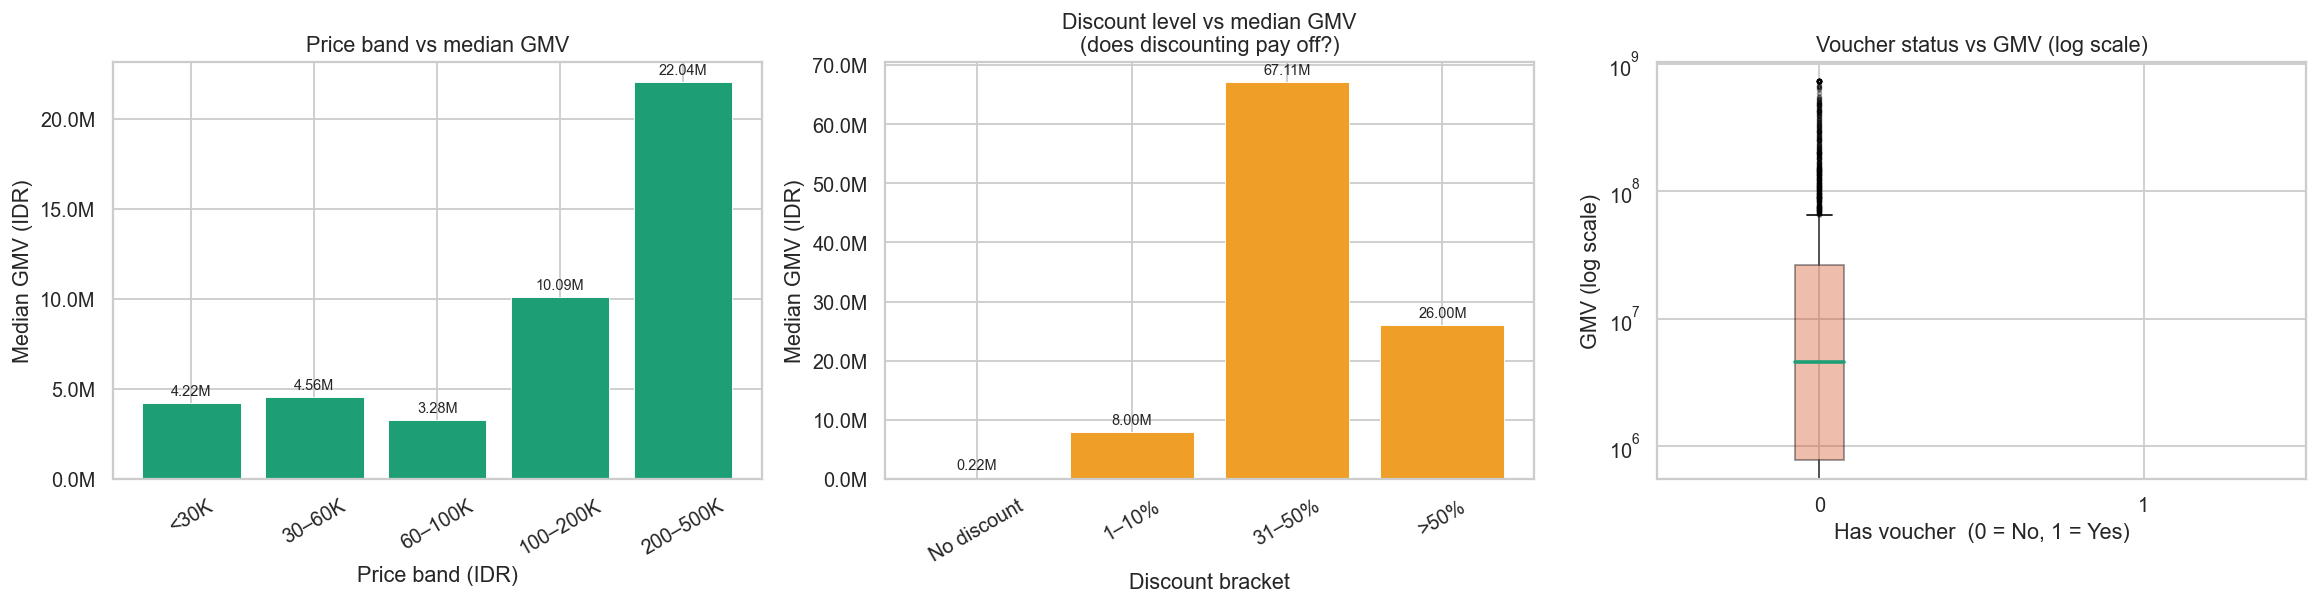


Spearman ρ — discount vs GMV : +0.049
Spearman ρ — voucher  vs GMV : -0.071

Median GMV with    voucher: IDR 0
Median GMV without voucher: IDR 4,622,500
Voucher GMV uplift         : 0.00x


In [41]:
# ── Do pricing tactics drive more sales in this category? ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Price band vs median GMV
price_gmv = df.groupby('price_band', observed=True)['gmv_cal'].median()
axes[0].bar(price_gmv.index, price_gmv.values,
            color=TEAL, edgecolor='white', lw=0.5)
axes[0].set_title('Price band vs median GMV')
axes[0].set_xlabel('Price band (IDR)')
axes[0].set_ylabel('Median GMV (IDR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)
for i, (_, val) in enumerate(price_gmv.items()):
    axes[0].text(i, val + price_gmv.max()*0.02,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

# (b) Discount bracket vs median GMV
df['discount_bracket'] = pd.cut(
    df['discount'],
    bins=[-1, 0, 10, 20, 30, 50, 100],
    labels=['No discount','1–10%','11–20%','21–30%','31–50%','>50%']
)
disc_gmv = df.groupby('discount_bracket', observed=True)['gmv_cal'].median()
axes[1].bar(disc_gmv.index, disc_gmv.values,
            color=AMBER, edgecolor='white', lw=0.5)
axes[1].set_title('Discount level vs median GMV\n(does discounting pay off?)')
axes[1].set_xlabel('Discount bracket')
axes[1].set_ylabel('Median GMV (IDR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=30)
for i, (_, val) in enumerate(disc_gmv.items()):
    axes[1].text(i, val + disc_gmv.max()*0.02,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

# (c) Voucher status vs GMV — boxplot on log scale
df.boxplot(column='gmv_cal', by='voucher_status', ax=axes[2],
           patch_artist=True,
           boxprops=dict(facecolor=CORAL, alpha=0.4),
           medianprops=dict(color=TEAL, lw=2),
           flierprops=dict(marker='o', ms=2, alpha=0.2))
axes[2].set_yscale('log')
axes[2].set_title('Voucher status vs GMV (log scale)')
axes[2].set_xlabel('Has voucher  (0 = No, 1 = Yes)')
axes[2].set_ylabel('GMV (log scale)')
fig.suptitle('')

plt.tight_layout()
plt.show()

rho_d, _ = stats.spearmanr(df['discount'], df['gmv_cal'])
rho_v, _ = stats.spearmanr(df['voucher_status'], df['gmv_cal'])
print(f"\nSpearman ρ — discount vs GMV : {rho_d:+.3f}")
print(f"Spearman ρ — voucher  vs GMV : {rho_v:+.3f}")
print(f"\nMedian GMV with    voucher: IDR {df[df['voucher_status']==1]['gmv_cal'].median():,.0f}")
print(f"Median GMV without voucher: IDR {df[df['voucher_status']==0]['gmv_cal'].median():,.0f}")
uplift = df[df['voucher_status']==1]['gmv_cal'].median() / \
         df[df['voucher_status']==0]['gmv_cal'].median()
print(f"Voucher GMV uplift         : {uplift:.2f}x")

#### [Insight] Correlation between discount and voucher to GMV is minimal with discount moving in the same direction but surprisingly voucher in opposite direction.

/var/folders/g_/fmz6fbfx0l96hfjsv2764ypw0000gn/T/ipykernel_96410/2202728813.py:42: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  plt.tight_layout()
/Users/angelinemarcellelukito/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


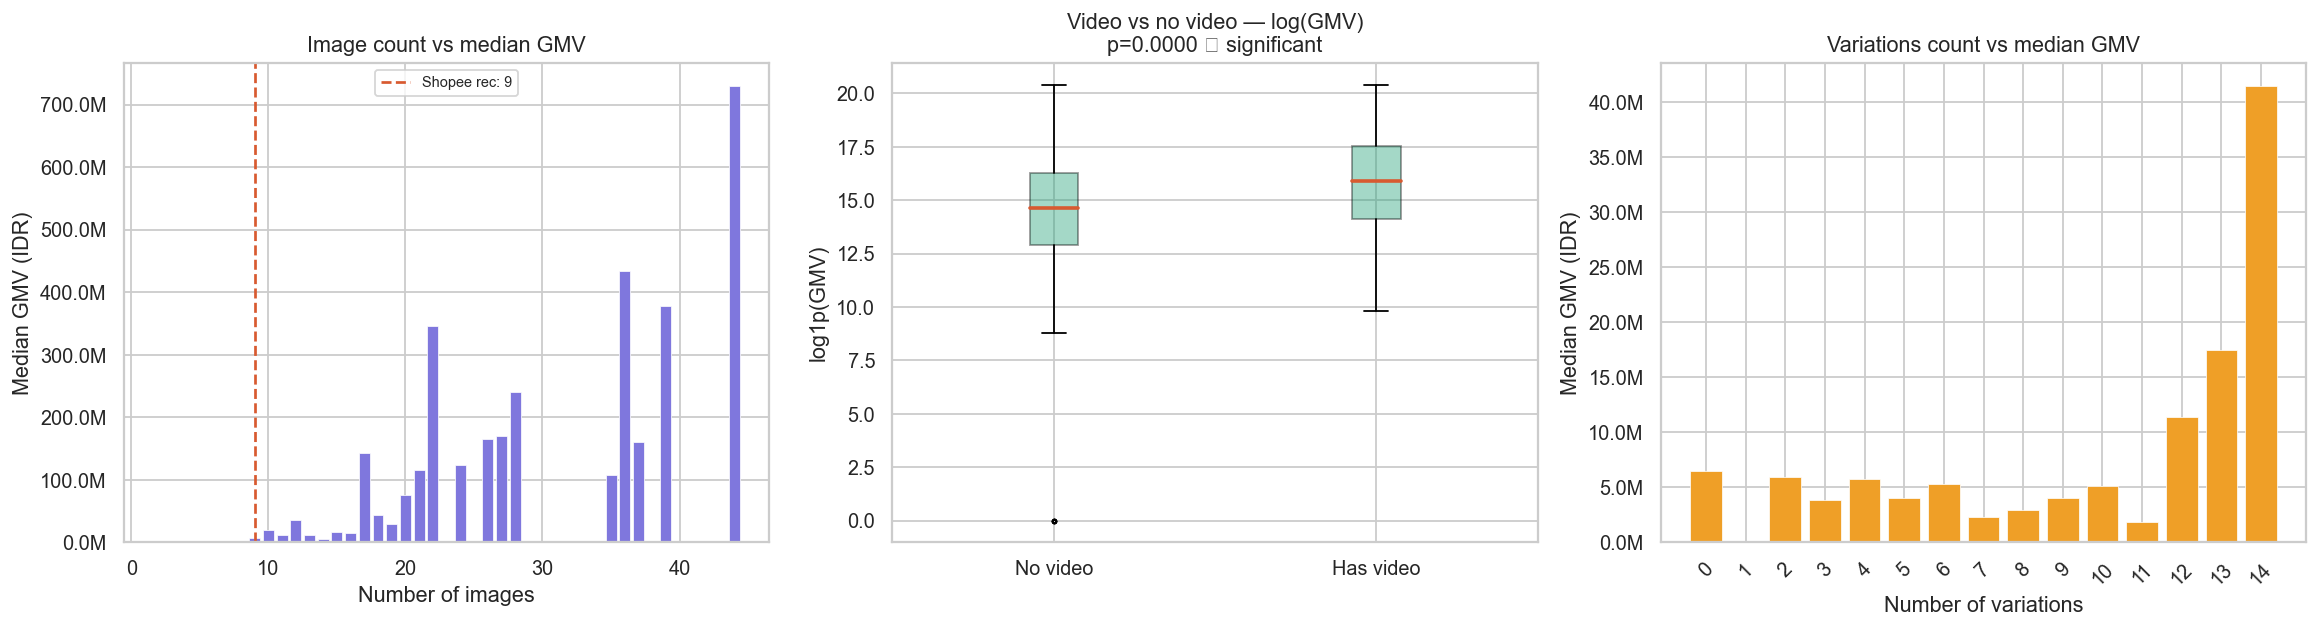


Spearman ρ — image_count     vs GMV: +0.386
Spearman ρ — variations_count vs GMV: -0.067

Median GMV — has video : IDR 7,910,100
Median GMV — no video  : IDR 2,288,400
Video GMV uplift       : 3.46x


In [42]:
# ── Images, video, variations — do they move the needle? ──────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Image count vs median GMV
img_gmv = df.groupby('image_count')['gmv_cal'].median()
axes[0].bar(img_gmv.index, img_gmv.values,
            color=PURPLE, edgecolor='white', lw=0.4)
axes[0].axvline(9, color=CORAL, lw=1.5,
               linestyle='--', label='Shopee rec: 9')
axes[0].set_title('Image count vs median GMV')
axes[0].set_xlabel('Number of images')
axes[0].set_ylabel('Median GMV (IDR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].legend(fontsize=8)

# (b) Video vs no video — Mann-Whitney U test
has_vid = df[df['video_count'] > 0]['gmv_cal']
no_vid  = df[df['video_count'] == 0]['gmv_cal']
_, u_pval = stats.mannwhitneyu(has_vid, no_vid, alternative='two-sided')
axes[1].boxplot(
    [np.log1p(no_vid), np.log1p(has_vid)],
    labels=['No video', 'Has video'],
    patch_artist=True,
    boxprops=dict(facecolor=TEAL, alpha=0.4),
    medianprops=dict(color=CORAL, lw=2),
    flierprops=dict(marker='o', ms=2, alpha=0.2)
)
sig_label = f'p={u_pval:.4f} {"✓ significant" if u_pval < 0.05 else "✗ not significant"}'
axes[1].set_title(f'Video vs no video — log(GMV)\n{sig_label}')
axes[1].set_ylabel('log1p(GMV)')

# (c) Variations count vs median GMV
var_gmv = df.groupby('variations_count')['gmv_cal'].median().head(15)
axes[2].bar(var_gmv.index.astype('str'), var_gmv.values,
            color=AMBER, edgecolor='white', lw=0.4)
axes[2].set_title('Variations count vs median GMV')
axes[2].set_xlabel('Number of variations')
axes[2].set_ylabel('Median GMV (IDR)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

rho_img, _ = stats.spearmanr(df['image_count'], df['gmv_cal'])
rho_var, _ = stats.spearmanr(df['variations_count'], df['gmv_cal'])
print(f"\nSpearman ρ — image_count     vs GMV: {rho_img:+.3f}")
print(f"Spearman ρ — variations_count vs GMV: {rho_var:+.3f}")
print(f"\nMedian GMV — has video : IDR {has_vid.median():,.0f}")
print(f"Median GMV — no video  : IDR {no_vid.median():,.0f}")
print(f"Video GMV uplift       : {has_vid.median()/no_vid.median():.2f}x")

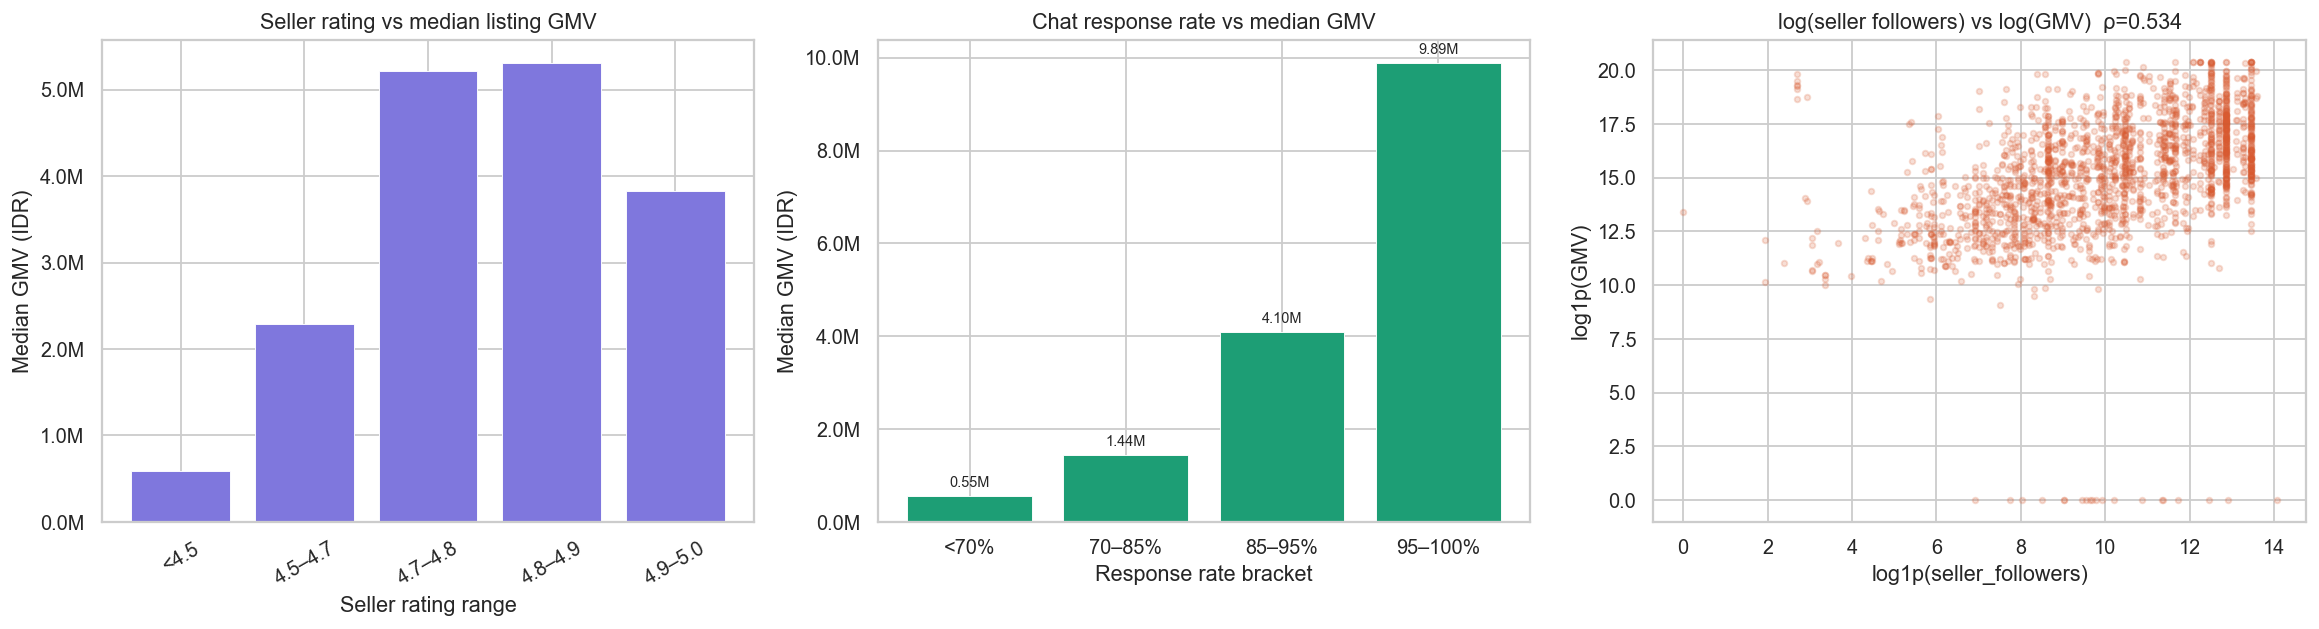


── Seller metric correlations with gmv_cal ──
  seller_rating                              ρ=-0.062  ***
  seller_followers                           ρ=+0.534  ***
  seller_products                            ρ=+0.136  ***
  seller_chats_responded_percentage          ρ=+0.318  ***
  seller_chat_time_reply                     ρ=+0.092  ***


In [43]:
# ── Does seller health predict per-listing GMV? ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Seller rating bucket vs median GMV
df['seller_rating_bucket'] = pd.cut(
    df['seller_rating'],
    bins=[0, 4.5, 4.7, 4.8, 4.9, 5.01],
    labels=['<4.5', '4.5–4.7', '4.7–4.8', '4.8–4.9', '4.9–5.0']
)
sr_gmv = df.groupby('seller_rating_bucket', observed=True)['gmv_cal'].median()
axes[0].bar(sr_gmv.index, sr_gmv.values,
            color=PURPLE, edgecolor='white', lw=0.5)
axes[0].set_title('Seller rating vs median listing GMV')
axes[0].set_xlabel('Seller rating range')
axes[0].set_ylabel('Median GMV (IDR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=30)

# (b) Chat response rate buckets vs median GMV
df['chat_bucket'] = pd.cut(
    df['seller_chats_responded_percentage'],
    bins=[0, 70, 85, 95, 100.1],
    labels=['<70%', '70–85%', '85–95%', '95–100%']
)
chat_gmv = df.groupby('chat_bucket', observed=True)['gmv_cal'].median()
axes[1].bar(chat_gmv.index, chat_gmv.values,
            color=TEAL, edgecolor='white', lw=0.5)
axes[1].set_title('Chat response rate vs median GMV')
axes[1].set_xlabel('Response rate bracket')
axes[1].set_ylabel('Median GMV (IDR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
for i, (_, val) in enumerate(chat_gmv.items()):
    axes[1].text(i, val + chat_gmv.max()*0.02,
                 f'{val/1e6:.2f}M', ha='center', fontsize=8)

# (c) Seller followers (log) vs listing GMV
sample = df.sample(min(2000, len(df)), random_state=42)
axes[2].scatter(np.log1p(sample['seller_followers']),
               np.log1p(sample['gmv_cal']),
               alpha=0.2, s=10, color=CORAL)
rho_sf, _ = stats.spearmanr(df['seller_followers'], df['gmv_cal'])
axes[2].set_title(f'log(seller followers) vs log(GMV)  ρ={rho_sf:.3f}')
axes[2].set_xlabel('log1p(seller_followers)')
axes[2].set_ylabel('log1p(GMV)')

plt.tight_layout()
plt.show()

print("\n── Seller metric correlations with gmv_cal ──")
seller_metrics = ['seller_rating', 'seller_followers', 'seller_products',
                  'seller_chats_responded_percentage', 'seller_chat_time_reply']
for col in seller_metrics:
    valid = df[[col, 'gmv_cal']].dropna()
    rho, pval = stats.spearmanr(valid[col], valid['gmv_cal'])
    sig = '***' if pval < 0.001 else ('** ' if pval < 0.01 else
          ('*  ' if pval < 0.05 else 'ns '))
    print(f"  {col:42} ρ={rho:+.3f}  {sig}")

#### [Insight] Seller followers surprisingly play a big part on GMV with seller respond percentage coming second.

In [44]:
# ── Compute ρ for every feature vs gmv_cal, rank by strength ──────
levers = [
    'reviews', 'favorite', 'rating', 'final_price',
    'discount', 'image_count', 'video_count', 'variations_count',
    'voucher_status', 'seller_rating', 'seller_followers',
    'seller_products', 'seller_chats_responded_percentage',
    'seller_chat_time_reply', 'stock',
]
# Note: 'sold' intentionally excluded here —
# it's near-identical to gmv_cal and would cause leakage

rows = []
for col in levers:
    valid = df[[col, 'gmv_cal']].dropna()
    rho, pval = stats.spearmanr(valid[col], valid['gmv_cal'])
    rows.append({
        'Feature'       : col,
        'ρ (Spearman)'  : round(rho, 3),
        'Significance'  : ('***' if pval<.001 else '** ' if pval<.01
                            else '*  ' if pval<.05 else 'ns '),
        'Direction'     : '↑ more = better' if rho > 0 else '↓ less = better',
        'Lever strength': ('Strong'   if abs(rho) > 0.4 else
                           'Moderate' if abs(rho) > 0.2 else 'Weak'),
        'Roadmap action': (
            'Prioritise getting reviews — #1 growth lever'   if col == 'reviews'
            else 'Maintain rating ≥ threshold from Cell 21'     if col == 'rating'
            else 'Use vouchers — direct GMV uplift'              if col == 'voucher_status'
            else 'Respond to chats quickly'                     if col == 'seller_chats_responded_percentage'
            else 'Upload 9+ images per listing'                 if col == 'image_count'
            else 'Add a product video'                          if col == 'video_count'
            else 'Offer variations (colour/size options)'        if col == 'variations_count'
            else '—'
        )
    })

lever_df = (pd.DataFrame(rows)
              .sort_values('ρ (Spearman)', key=abs, ascending=False)
              .reset_index(drop=True))
lever_df.index += 1
lever_df.index.name = 'Rank'

display(lever_df.style
    .background_gradient(subset=['ρ (Spearman)'], cmap='RdYlGn')
    .set_caption('Phase 3: Ranked GMV levers — seller roadmap skeleton')
    .hide(axis='index')
)

# Export for reference in later phases
lever_df.to_csv('phase3_gmv_levers.csv', index=True)
print("\nSaved → phase3_gmv_levers.csv")

Feature,ρ (Spearman),Significance,Direction,Lever strength,Roadmap action
reviews,0.957000,***,↑ more = better,Strong,Prioritise getting reviews — #1 growth lever
favorite,0.743000,***,↑ more = better,Strong,—
seller_followers,0.534000,***,↑ more = better,Strong,—
rating,-0.397000,***,↓ less = better,Moderate,Maintain rating ≥ threshold from Cell 21
image_count,0.386000,***,↑ more = better,Moderate,Upload 9+ images per listing
seller_chats_responded_percentage,0.318000,***,↑ more = better,Moderate,Respond to chats quickly
stock,0.253000,***,↑ more = better,Moderate,—
video_count,0.235000,***,↑ more = better,Moderate,Add a product video
seller_products,0.136000,***,↑ more = better,Weak,—
final_price,0.111000,***,↑ more = better,Weak,—



Saved → phase3_gmv_levers.csv
